# Week 6 Day 4 Lab


In [1]:
# run this cell first!

import numpy as np
np.random.seed(42)

### Problem 1
Generate 100,000 samples using `np.random.uniform(0,1)` and compute the average so far at each sample. Plot the data. What do you notice?

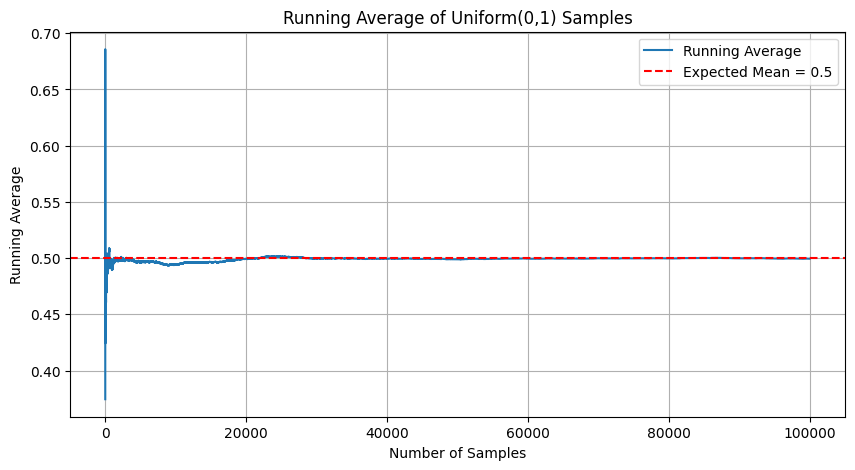

In [2]:
import matplotlib.pyplot as plt

samples = np.random.uniform(0, 1, 100000)

running_average = np.cumsum(samples) / np.arange(1, len(samples) + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_average, label="Running Average")
plt.axhline(y=0.5, color='r', linestyle='--', label="Expected Mean = 0.5")
plt.xlabel("Number of Samples")
plt.ylabel("Running Average")
plt.title("Running Average of Uniform(0,1) Samples")
plt.legend()
plt.grid(True)

# The numbers begin concentrating more and more toward 0.5 as the value gets higher

### Problem 2
We want to compute $\int_0^1 x^2dx$. To do so, generate random points between 0 and 1. Accept them if they are below and reject them if they are above. Compute the average of the accepted values and plot the accepted vs rejected points.

Estimated Integral = 0.33435
Exact Integral = 0.3333333333333333


C:\Users\CharlesLiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


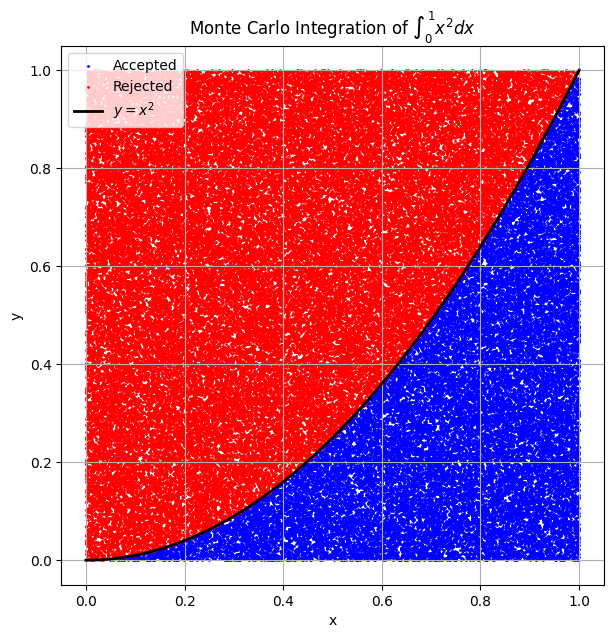

In [3]:
N = 100000

x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

accepted = y <= x**2
rejected = ~accepted

integral_estimate = np.mean(accepted)

print("Estimated Integral =", integral_estimate)
print("Exact Integral =", 1/3)

plt.figure(figsize=(7,7))
plt.scatter(x[accepted], y[accepted], s=1, color='blue', label='Accepted')
plt.scatter(x[rejected], y[rejected], s=1, color='red', label='Rejected')

x_curve = np.linspace(0, 1, 200)
plt.plot(x_curve, x_curve**2, color='black', linewidth=2, label=r'$y=x^2$')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Monte Carlo Integration of $\\int_0^1 x^2dx$")
plt.legend()
plt.grid(True)
plt.show()

### Problem 3 
Write a function that will do Problem 2 for any function and bounds.

Estimated Integral: 27.046709999999997
Exact Integral:  27.0


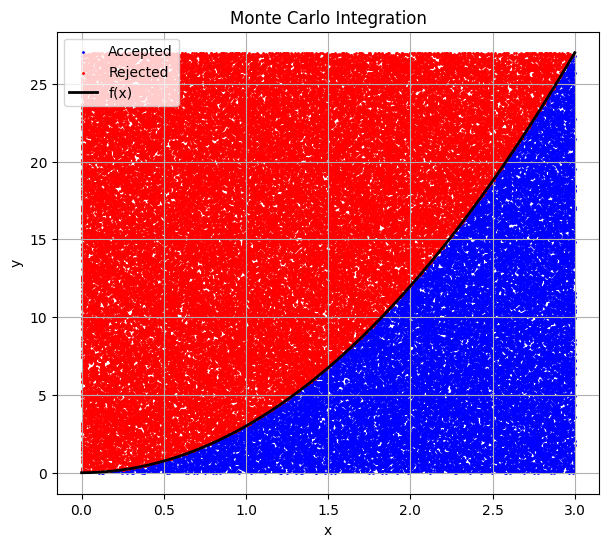

In [11]:
from scipy.integrate import quad

def monte_carlo_integral(f, a, b, N=100000):
    x_plot = np.linspace(a, b, 1000)
    ymax = np.max(f(x_plot))
    
    x = np.random.uniform(a, b, N)
    y = np.random.uniform(0, ymax, N)

    accepted = y <= f(x)
    rejected = ~accepted

    area_rectangle = (b - a) * ymax
    integral = area_rectangle * np.mean(accepted)

    exact, error = quad(f, a, b)
    print("Estimated Integral:", integral)
    print("Exact Integral: ", exact)

    plt.figure(figsize=(7, 6))
    plt.scatter(x[accepted], y[accepted], s=1, color="blue", label="Accepted")
    plt.scatter(x[rejected], y[rejected], s=1, color="red", label="Rejected")

    plt.plot(x_plot, f(x_plot), color="black", linewidth=2, label="f(x)")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Monte Carlo Integration")
    plt.legend()
    plt.grid(True)
    plt.show()

    return integral

estimate = monte_carlo_integral(lambda x: 3*x**2, 0, 3)

### Problem 4

Estimate $\pi$ using one of the functions from lecture with:

- 1,000 samples
- 10,000 samples
- 100,000 samples

Compare the results with the true value of $\pi$.

In [15]:
import numpy as np

def estimate_pi(N):
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)

    inside = x**2 + y**2 <= 1

    pi_estimate = 4 * np.mean(inside)

    return pi_estimate

true_pi = np.pi

samples = [1000, 10000, 100000]

for N in samples:
    estimate = estimate_pi(N)
    print("N =", N)
    print("Estimated pi = ", estimate)
    print("True pi      = ", true_pi)
    print("Error       = ", abs(true_pi - estimate))

N = 1000
Estimated pi =  3.156
True pi      =  3.141592653589793
Error       =  0.014407346410207023
N = 10000
Estimated pi =  3.13
True pi      =  3.141592653589793
Error       =  0.011592653589793223
N = 100000
Estimated pi =  3.14068
True pi      =  3.141592653589793
Error       =  0.0009126535897929777
